Total detected bursts: 277


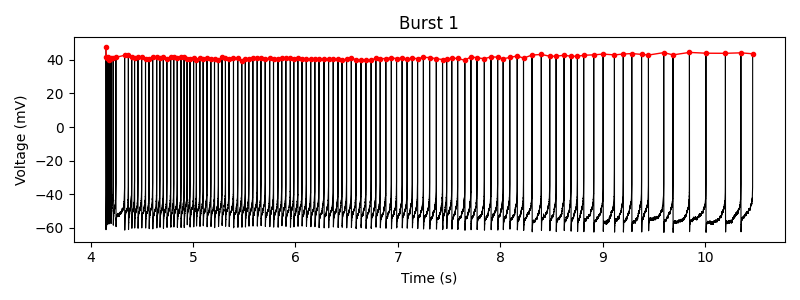

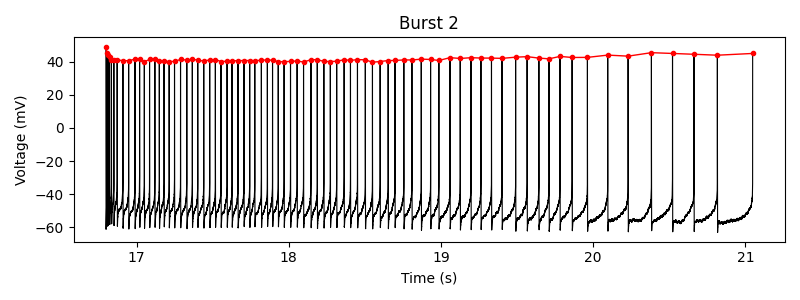

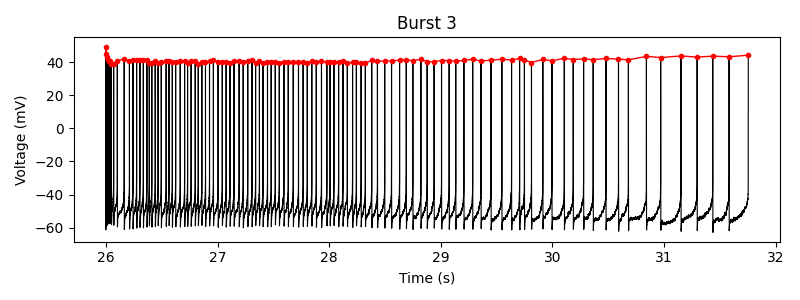

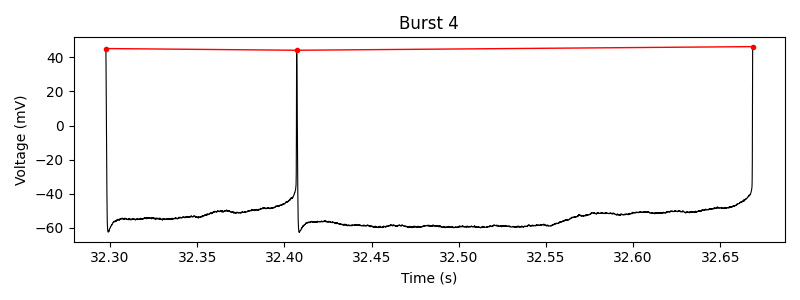

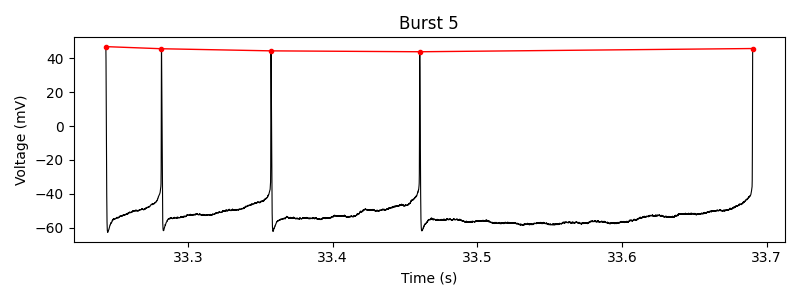

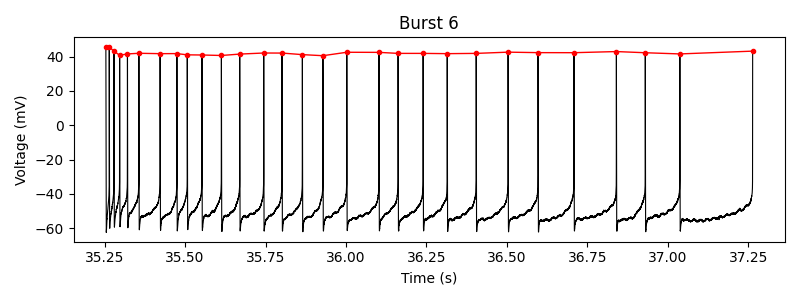

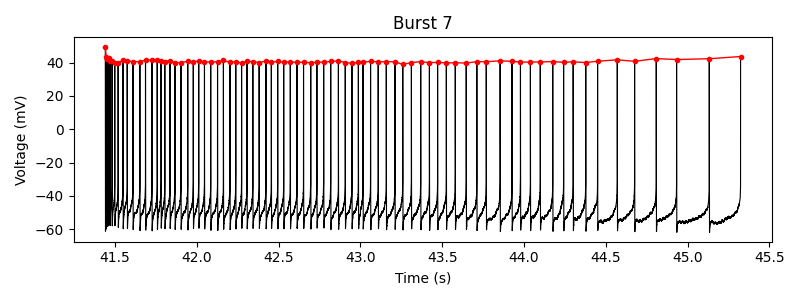

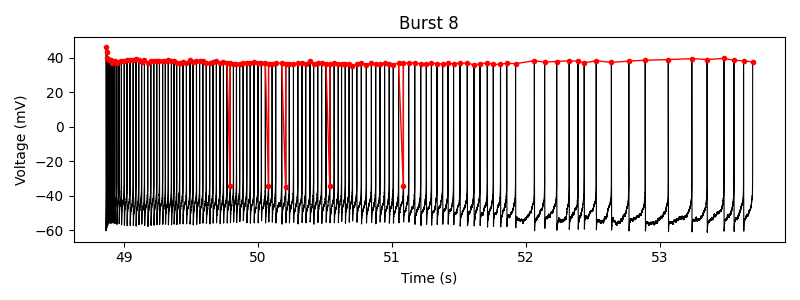

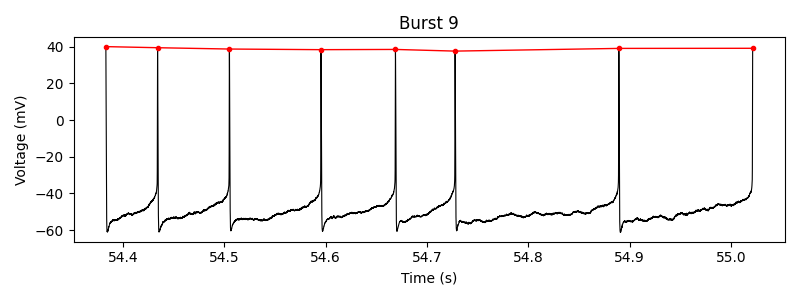

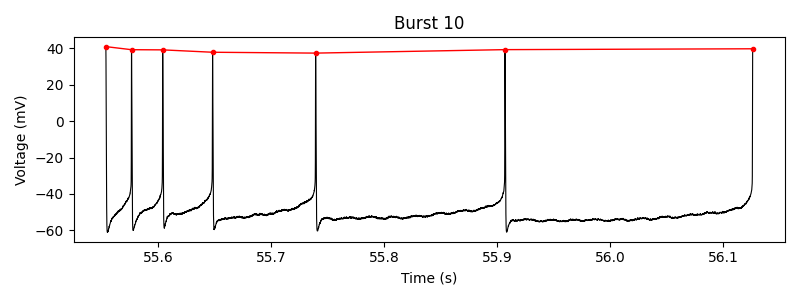

In [1]:

# DEEPLY COMMENTED CODE: SPIKE & BURST DETECTION + VISUALIZATION


# The explanations below cover each step in depth, numerical details,
# assumptions, and good practices are emphasized.


# Import required libraries

import pyabf
# pyabf is a specialized library for reading Axon Binary Files (.abf),
# commonly used in electrophysiology (patch-clamp recordings, etc.).
# It provides easy access to sweeps (repeated traces), sample rate,
# and metadata such as units and channel labels.

import numpy as np
# NumPy handles efficient array operations and numerical computations.
# We'll use it for concatenation, logical masking, and vector math.

import matplotlib.pyplot as plt
# Matplotlib provides plotting capabilities for visualization of signals
# and detected bursts.

from scipy.signal import find_peaks
# find_peaks finds local maxima in 1D arrays, with optional constraints
# (like minimum height, distance, or prominence). Perfect for detecting spikes.

# Enable interactive plotting (useful in Jupyter)
%matplotlib widget
# %matplotlib widget enables interactive zooming/panning in notebooks.
# If running this script outside Jupyter, remove this line or replace with:
# %matplotlib inline  (for static plots)


# Load the electrophysiological data

file_path = "bursting/cell89basal.abf"  
# Path to your .abf data file.
# Each ABF typically contains several sweeps (individual trials) of voltage recordings.

abf = pyabf.ABF(file_path)
# Load the ABF file into memory.
# After loading, abf.sweepCount tells how many sweeps exist,
# and abf.dataRate gives the sampling frequency (in Hz).



# Concatenate all sweeps into one long signal

# Each sweep is a separate recording, but here we want to analyze them together
# as a continuous trace. The trick below uses Python's “or” short-circuiting
# to call abf.setSweep(i) (which sets internal state) and then immediately
# returns abf.sweepY (the actual signal data).

signal = np.concatenate([
    abf.setSweep(i) or abf.sweepY for i in range(abf.sweepCount)
])
# - abf.setSweep(i) loads sweep i's data into abf.sweepY (a NumPy array).
# - The “or” expression ensures abf.sweepY is returned for each iteration.
# - np.concatenate stitches all sweeps end-to-end into one long vector.

dt = 1.0 / abf.dataRate  
# Sampling interval (seconds per sample). If abf.dataRate = 10 kHz, dt = 0.0001 s.

time = np.arange(len(signal)) * dt  


# Spike detection

threshold = -35  # mV


spike_indices, _ = find_peaks(signal, height=threshold)
# find_peaks returns indices of local maxima and an optional dictionary of properties.
# Here, we use the 'height' argument to only accept peaks >= threshold.
# Note: find_peaks finds *local maxima*. If your spikes are negative, invert the signal.

spike_times = time[spike_indices]
# Convert indices to actual time points using the time vector.
# Each spike_time corresponds to the detected peak's timestamp.



# Burst detection based on ISI (Interspike Interval)

isi = np.diff(spike_times)
# ISI = time difference between consecutive spikes (seconds).
# Small ISIs indicate rapid firing (potential bursts),
# large ISIs indicate separate bursts or tonic firing.

burst_threshold = 0.3  # s
# If the ISI between spikes is < 0.3 s, they're considered part of the same burst.

# Prepare to accumulate bursts
bursts = []  # will hold lists of spike times per burst

# Initialize with the first spike
current_burst = [spike_times[0]]

# Iterate through ISIs to group spikes
for i in range(1, len(isi)):
    if isi[i - 1] < burst_threshold:
        # The gap between this spike and the previous one is small,
        # so we consider it part of the same burst.
        current_burst.append(spike_times[i])
    else:
        # The gap is too large, burst ends here.
        # Save the current burst only if it contains >1 spike (a real burst)
        if len(current_burst) > 1:
            bursts.append(current_burst)
        # Start a new burst with the current spike
        current_burst = [spike_times[i]]

# After looping, check if the final burst qualifies
if len(current_burst) > 1:
    bursts.append(current_burst)

# After this section:
# - bursts is a list of lists, where each sublist contains the spike times of one burst.
# - Each burst is defined by spikes with ISIs < 0.3 s internally,
#   and separated by larger gaps between bursts.

print(f"Total detected bursts: {len(bursts)}")
# Diagnostic output, tells you how many bursts were found overall.



# Visualization: plot the first few bursts

n_bursts_to_plot = min(10, len(bursts))
# We'll visualize up to 10 bursts, or fewer if fewer are detected.

for i in range(n_bursts_to_plot):
    burst = bursts[i]  # spike times belonging to this burst

    # Create a boolean mask selecting samples within the burst window.
    # We define the burst window as from the first to the last spike of the burst.
    mask = (time >= burst[0]) & (time <= burst[-1])

    # Extract time and voltage for this burst
    t_burst = time[mask]
    s_burst = signal[mask]

    # Identify which spikes (from spike_times) fall inside this burst window
    burst_peak_mask = (spike_times >= burst[0]) & (spike_times <= burst[-1])
    burst_spike_times = spike_times[burst_peak_mask]
    burst_spike_values = signal[spike_indices][burst_peak_mask]
    # burst_spike_values are the actual voltages at the spike peaks.


    # Plot this burst
    plt.figure(figsize=(8, 3))
    plt.plot(t_burst, s_burst, lw=0.8, color="black")
    # Plot the raw voltage trace in black.

    plt.plot(burst_spike_times, burst_spike_values, "ro", markersize=3)
    # Overlay red dots on detected spike peaks.

    plt.plot(burst_spike_times, burst_spike_values, "r-", lw=1)
    # Connect spike peaks within the burst using red lines to visualize firing pattern.

    plt.xlabel("Time (s)")
    plt.ylabel("Voltage (mV)")
    plt.title(f"Burst {i+1}")
    plt.tight_layout()
    plt.show()
    # Each figure shows one burst waveform with annotated spikes.

Total detected bursts: 277


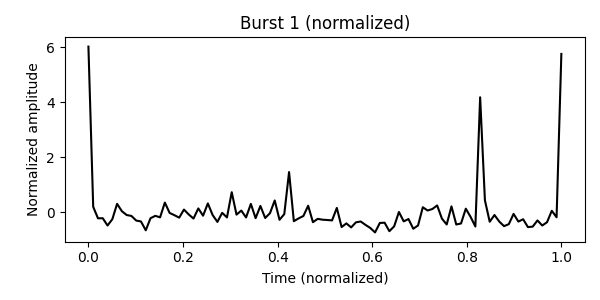

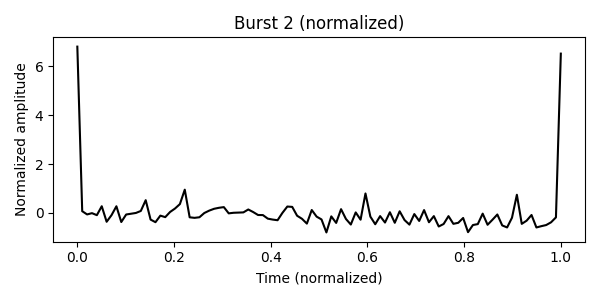

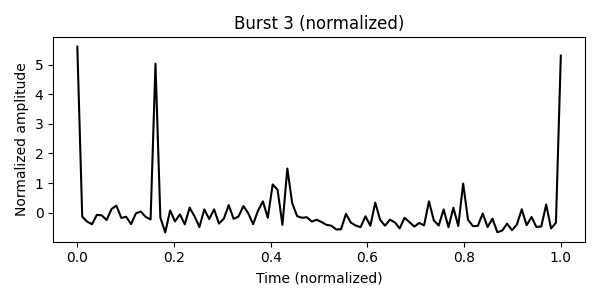

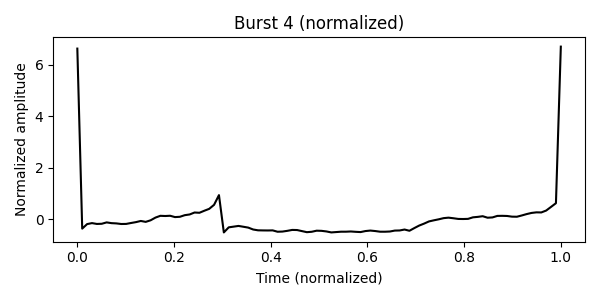

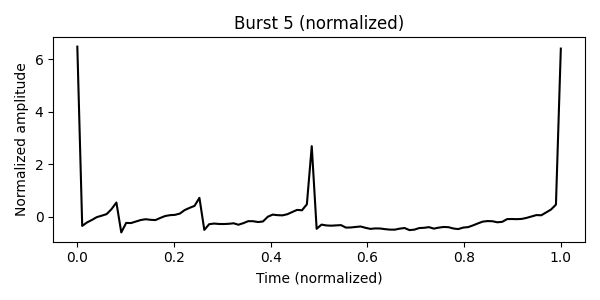

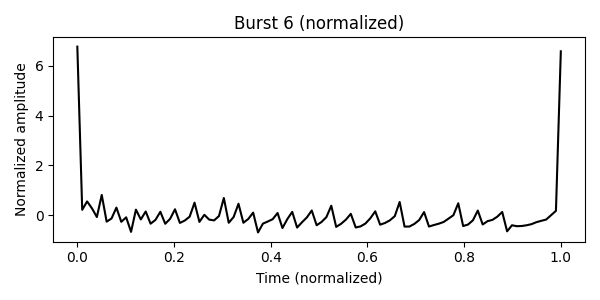

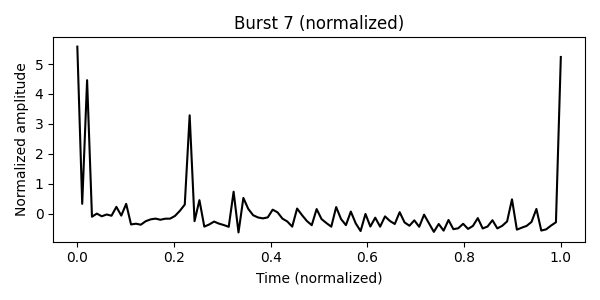

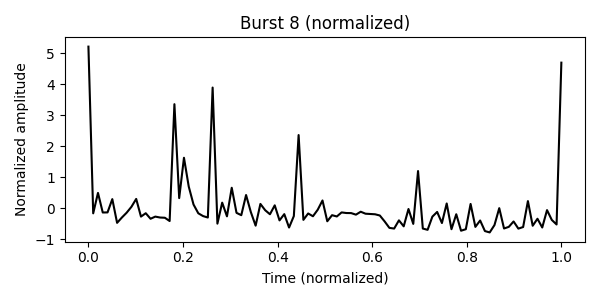

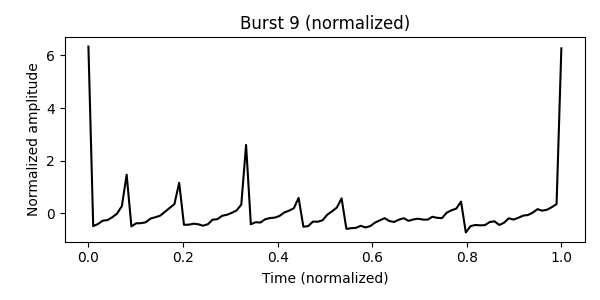

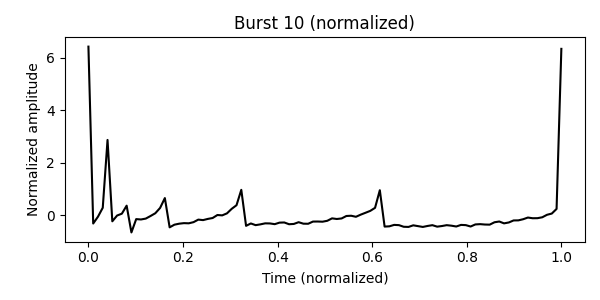

In [2]:

#  BURST NORMALIZATION PIPELINE

#  This script loads intracellular electrophysiology data (.abf),
#  detects spikes and bursts, and then normalizes each burst
#  in both time (duration) and amplitude for comparison.

import pyabf                             # Library to read Axon Binary Files (.abf)
import numpy as np                        # For numerical operations and arrays
import matplotlib.pyplot as plt           # For visualization
from scipy.signal import find_peaks       # Used for spike detection
from scipy.interpolate import interp1d    # Used to rescale bursts in time


# LOAD ABF FILE

file_path = "bursting/cell89basal.abf"    # Path to the electrophysiological recording
abf = pyabf.ABF(file_path)                # Load the ABF object containing sweeps


# CONCATENATE ALL SWEEPS INTO A SINGLE CONTINUOUS SIGNAL

signal = np.concatenate([abf.setSweep(i) or abf.sweepY for i in range(abf.sweepCount)])

# Calculate sampling interval (seconds per data point)
dt = 1.0 / abf.dataRate

# Generate time vector corresponding to the concatenated signal
time = np.arange(len(signal)) * dt


# SPIKE DETECTION


threshold = -35  # mV
spike_indices, _ = find_peaks(signal, height=threshold)

# Convert spike indices into real time (seconds)
spike_times = time[spike_indices]


# BURST DETECTION


isi = np.diff(spike_times)        # Compute time difference between consecutive spikes
burst_threshold = 0.3             # Maximum ISI (s) to be considered part of the same burst

bursts = []                       # List to store all detected bursts
current_burst = [spike_times[0]]  # Initialize the first burst with the first spike

# Loop through each ISI to separate bursts
for i in range(1, len(isi)):
    if isi[i-1] < burst_threshold:
        # If ISI is smaller than threshold, still inside the same burst
        current_burst.append(spike_times[i])
    else:
        # Otherwise, the burst ended
        if len(current_burst) > 1:
            # Only store bursts containing at least 2 spikes
            bursts.append(current_burst)
        # Start a new burst with the current spike
        current_burst = [spike_times[i]]

# After loop, check if the last burst is valid and append it
if len(current_burst) > 1:
    bursts.append(current_burst)

# Print summary of detected bursts
print(f"Total detected bursts: {len(bursts)}")


# NORMALIZATION FUNCTIONS

# Once bursts are detected, we normalize them so that:
# 1) Each burst has the same duration (rescaled in time)
# 2) Each burst has comparable amplitude (z-score normalization)

def normalize_y(signal_segment):
    #Normalizes the amplitude of a signal segment using z-score normalization.
    #Formula: (x - mean) / std
    #This centers the burst around 0 and scales it so that its standard deviation = 1.
    
    return (signal_segment - np.mean(signal_segment)) / np.std(signal_segment)


def rescale_x(time_segment, signal_segment, n_points=100):
    
    # Rescales a burst to have a standardized duration.
    # The signal is interpolated so that it contains exactly n_points samples,
    # regardless of its original duration.
    
    # This allows comparing bursts of different lengths by "stretching" or
    # "compressing" them along the time axis proportionally.
    
    # Create an interpolation function over normalized time [0,1]
    f = interp1d(np.linspace(0, 1, len(signal_segment)), signal_segment)
    
    # Evaluate it over a uniform 0–1 grid of n_points samples
    return f(np.linspace(0, 1, n_points))


# VISUALIZATION: PLOT FIRST 10 NORMALIZED BURSTS

# We now apply the normalization functions to the first 10 detected bursts
# and visualize them, so each burst appears aligned and standardized.

n_bursts_to_plot = min(10, len(bursts))  # Plot up to 10 bursts or fewer if less exist

for i in range(n_bursts_to_plot):
    burst = bursts[i]

    # Extract the portion of the signal corresponding to the current burst
    mask = (time >= burst[0]) & (time <= burst[-1])
    t_burst = time[mask]     # Time window of the burst
    s_burst = signal[mask]   # Voltage trace during the burst

    # Normalize burst duration (time axis)
    s_rescaled = rescale_x(t_burst, s_burst, n_points=100)

    # Normalize burst amplitude (voltage axis)
    s_normalized = normalize_y(s_rescaled)


    # Plot the normalized burst
    # The x-axis (0 to 1) represents the normalized time course,
    # and the y-axis represents z-scored voltage amplitude.
    plt.figure(figsize=(6, 3))
    plt.plot(np.linspace(0, 1, 100), s_normalized, "k-")
    plt.title(f"Burst {i+1} (normalized)")
    plt.xlabel("Time (normalized)")
    plt.ylabel("Normalized amplitude")
    plt.tight_layout()
    plt.show()


C:\Users\manur\AppData\Local\Temp\ipykernel_10532\806988319.py:147: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6, 3))


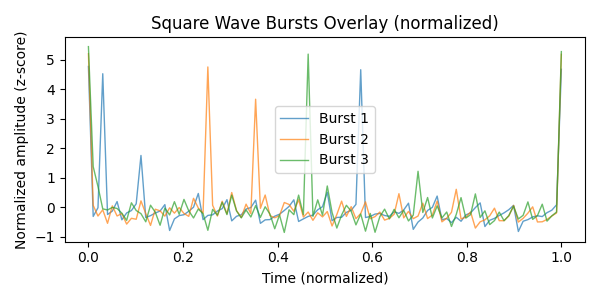

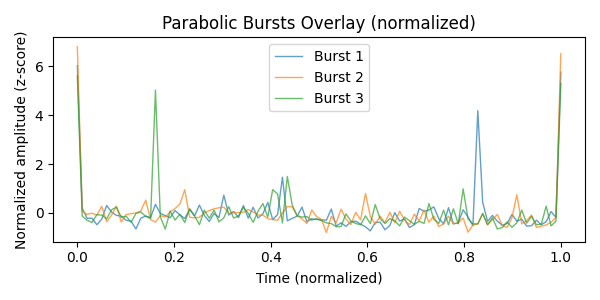

No bursts of type Other to plot.


In [3]:

# BURST CLASSIFICATION AND NORMALIZATION PIPELINE

import pyabf                              # Library for handling ABF
import numpy as np                        # Numerical computations
import matplotlib.pyplot as plt           # Visualization
from scipy.signal import find_peaks       # Spike detection tool
from scipy.interpolate import interp1d    # Used for temporal rescaling (normalizing burst length)


# STEP 1: LOAD DATA

# Load an ABF electrophysiology recording containing multiple sweeps.

file_path = "bursting/cell89basal.abf"    
abf = pyabf.ABF(file_path)                # Load ABF object into memory


# STEP 2: CONCATENATE SWEEPS INTO A SINGLE CONTINUOUS SIGNAL

signal = np.concatenate([abf.setSweep(i) or abf.sweepY for i in range(abf.sweepCount)])

# Compute time resolution (sampling interval) and total time vector
dt = 1.0 / abf.dataRate                   
time = np.arange(len(signal)) * dt        



# STEP 3: SPIKE DETECTION

# Detect action potentials (spikes) as local maxima above a threshold.
# find_peaks returns indices of points that qualify as peaks.

threshold = -35                           # voltage threshold (mV) for spike detection
spike_indices, _ = find_peaks(signal, height=threshold)
spike_times = time[spike_indices]         # convert indices to time values (s)


# STEP 4: BURST DETECTION BASED ON INTERSPIKE INTERVAL (ISI)

# A burst is a sequence of spikes that occur close together in time.
# The ISI (InterSpike Interval) is the time between consecutive spikes.

isi = np.diff(spike_times)                # vector of ISIs
burst_threshold = 0.3                  

bursts = []                            
current_burst = [spike_times[0]]          # initialize with the first spike time

# Loop through each ISI and decide if we are inside the same burst or starting a new one
for i in range(1, len(isi)):
    if isi[i-1] < burst_threshold:
        # If current ISI is short enough, continue the same burst
        current_burst.append(spike_times[i])
    else:
        # If ISI is long, burst ends here
        if len(current_burst) > 1:
            # Only keep as a burst if there were at least 2 spikes
            bursts.append((current_burst[0], current_burst[-1]))
        # Start a new burst with the current spike
        current_burst = [spike_times[i]]

# Add the final burst if it was not appended in the loop
if len(current_burst) > 1:
    bursts.append((current_burst[0], current_burst[-1]))


# STEP 5: BURST CLASSIFICATION BASED ON SHAPE
# Each burst can exhibit a different voltage trajectory:
#   - "Square Wave": burst minimum voltage > baseline (flat-bottom waveform)
#   - "Parabolic": burst minimum voltage < baseline (smooth concave waveform)
#   - "Other": ambiguous or noisy bursts

square_wave_bursts = []                   # lists to store classified bursts
parabolic_bursts = []
other_bursts = []

for i, (burst_start, burst_end) in enumerate(bursts):
    # Mask signal in burst window
    burst_mask = (time >= burst_start) & (time <= burst_end)
    burst_min = np.min(signal[burst_mask]) 

    # Compute baseline voltage before and after the burst
    # These define the "inter-burst" mean voltage, acting as a local baseline.
    prev_mean = np.mean(signal[(time > bursts[i-1][1]) & (time < burst_start)]) if i > 0 else np.nan
    next_mean = np.mean(signal[(time > burst_end) & (time < bursts[i+1][0])]) if i < len(bursts)-1 else np.nan

    # Average pre- and post-burst baselines, ignoring NaN values
    inter_mean = np.nanmean([prev_mean, next_mean])

    # Classification rule:
    # If the minimum voltage is ABOVE the baseline, flat or depolarized "Square Wave"
    # If the minimum voltage is BELOW the baseline, "Parabolic" (deep concave waveform)
    # Otherwise, "Other"
    if burst_min > inter_mean:
        square_wave_bursts.append((burst_start, burst_end))
    elif burst_min < inter_mean:
        parabolic_bursts.append((burst_start, burst_end))
    else:
        other_bursts.append((burst_start, burst_end))


# STEP 6: NORMALIZATION FUNCTIONS

# Bursts vary in amplitude and duration.
# To compare them directly, we normalize:
#   - Amplitude using z-score normalization
#   - Duration by resampling (interpolation) to a fixed number of points

def normalize_y(signal_segment):
    
    # Z-score normalization: centers and scales signal amplitude.
    # Formula: y_norm = (y - mean(y)) / std(y)
    # This ensures each burst has zero mean and unit variance.
    
    return (signal_segment - np.mean(signal_segment)) / np.std(signal_segment)


def rescale_x(time_segment, signal_segment, n_points=100):
  
    # Duration normalization via interpolation.
    # Maps the burst duration to a normalized scale [0, 1],
    # resampling it to exactly 'n_points' samples.
    
    # This allows comparison between bursts of different lengths.
    
    # Create interpolation function on normalized x-axis
    f = interp1d(np.linspace(0, 1, len(signal_segment)), signal_segment)
    # Evaluate it on uniform [0,1] grid
    return f(np.linspace(0, 1, n_points))


# STEP 7: FUNCTION TO OVERLAY NORMALIZED BURSTS OF THE SAME TYPE

# This function plots multiple bursts of the same type on top of each other
# after normalization, allowing comparison of waveform shape consistency.

def overlay_bursts(burst_list, burst_type, n=3):
    
    # Overlay up to 'n' normalized bursts of a specific type.
    # Each burst is rescaled in time and normalized in amplitude.

    if len(burst_list) == 0:
        print(f"No bursts of type {burst_type} to plot.")
        return

    n_to_plot = min(n, len(burst_list))   # plot at most n bursts
    plt.figure(figsize=(6, 3))

    # Loop over bursts of the given type
    for i in range(n_to_plot):
        start, end = burst_list[i]

        # Extract time and signal within burst window
        mask = (time >= start) & (time <= end)
        t_burst = time[mask]
        s_burst = signal[mask]

        # Apply normalization
        s_rescaled = rescale_x(t_burst, s_burst, n_points=100)
        s_normalized = normalize_y(s_rescaled)

        # Plot normalized burst trace
        plt.plot(np.linspace(0, 1, 100), s_normalized, lw=1, alpha=0.7, label=f'Burst {i+1}')

    # Format plot
    plt.title(f"{burst_type} Bursts Overlay (normalized)")
    plt.xlabel("Time (normalized)")
    plt.ylabel("Normalized amplitude (z-score)")
    plt.legend()
    plt.tight_layout()
    plt.show()


# STEP 8: VISUALIZE BURSTS BY TYPE
# Plot overlaid normalized examples for each category of burst.

overlay_bursts(square_wave_bursts, "Square Wave", n=3)
overlay_bursts(parabolic_bursts, "Parabolic", n=3)
overlay_bursts(other_bursts, "Other", n=3)

In [4]:

# Import Dependencies

import pyabf                     
import numpy as np               
from scipy.signal import find_peaks  
from scipy.interpolate import interp1d


# Signal Preprocessing Functions


def normalize_y(signal_segment):

   # Normalize the amplitude of a signal segment using z-score normalization.

    # This step removes amplitude differences between bursts caused by recording drift or intrinsic variability in neuron excitability. It converts each
    # burst's voltage trace to zero mean and unit variance, so shape analysis focuses purely on waveform morphology.

    # Parameters: signal_segment (np.ndarray): The burst segment (voltage trace).

    # Returns: np.ndarray: The normalized burst (zero mean, unit std).
    
    return (signal_segment - np.mean(signal_segment)) / np.std(signal_segment)


def rescale_x(time_segment, signal_segment, n_points=100):

    # Rescale (interpolate) the time axis of a burst to have uniform length.

    # Each burst may have a different duration, for comparison or ML analysis, we interpolate every burst to exactly n_points samples.

    # interp1d() constructs a function f(x) that maps normalized time [0,1] to the signal amplitude. We then re-sample uniformly in [0,1].

    # Parameters:
    #    time_segment (np.ndarray): Original time vector of the burst.
    #    signal_segment (np.ndarray): Corresponding voltage values.
    #    n_points (int): Target number of time points after rescaling.

    # Returns: np.ndarray: Interpolated voltage trace of fixed length n_points.

    f = interp1d(np.linspace(0, 1, len(signal_segment)), signal_segment)
    return f(np.linspace(0, 1, n_points))


def detect_spikes(signal, threshold=-35):

    # Detect action potentials (spikes) in a continuous signal trace.

    # find_peaks() identifies local maxima where voltage exceeds a given threshold, here -35 mV, which is typical for spike onset detection.

    # Parameters:
    #    signal (np.ndarray): Voltage trace (in mV).
    #    threshold (float): Minimum height to qualify as a spike.

    #Returns: np.ndarray: Indices of detected spike peaks.
    
    spike_indices, _ = find_peaks(signal, height=threshold)
    return spike_indices


def detect_bursts(spike_times, burst_threshold=0.3):

    # Identify bursts from detected spikes based on inter-spike intervals (ISI).

    # The idea: a burst is a cluster of spikes separated by less than burst_threshold seconds (here 0.3s). When the ISI exceeds this, it marks
    # the end of a burst.

    # Parameters:
    #    spike_times (np.ndarray): Times (s) of detected spikes.
    #    burst_threshold (float): Max time between spikes in the same burst.

    #Returns: list of tuples: Each tuple = (burst_start_time, burst_end_time)
   
    isi = np.diff(spike_times)  # ISI = difference between consecutive spike times
    bursts = []
    current_burst = [spike_times[0]]

    # Iterate through all inter-spike intervals to group spikes into bursts
    for i in range(1, len(isi)):
        if isi[i-1] < burst_threshold:
            # Spike is part of the same burst
            current_burst.append(spike_times[i])
        else:
            # ISI too long end of burst
            if len(current_burst) > 1:  # Only keep bursts with >1 spike
                bursts.append((current_burst[0], current_burst[-1]))
            current_burst = [spike_times[i]]

    # Append final burst if valid
    if len(current_burst) > 1:
        bursts.append((current_burst[0], current_burst[-1]))

    return bursts


def classify_bursts(bursts, signal, time):

    # Classify each burst according to its waveform morphology.

    # Conceptually:
    # - Square Wave: burst minimum is above surrounding baseline (sustained depolarization).
    # - Parabolic: burst minimum is below baseline (deep hyperpolarization rebound).
    # - Other: ambiguous or flat baseline.

    #For each burst:
    #  - Compute min voltage during burst.
    #  - Compute mean voltage before and after the burst (inter-burst baseline).
    #  - Compare burst_min to this average baseline.

    # Returns: Three lists of (start, end) tuples for each class.
   
    square_wave_bursts = []
    parabolic_bursts = []
    other_bursts = []

    for i, (burst_start, burst_end) in enumerate(bursts):
        # Extract segment corresponding to the burst
        burst_mask = (time >= burst_start) & (time <= burst_end)
        burst_min = np.min(signal[burst_mask])  # Minimum voltage within the burst

        # Compute mean voltage before and after burst (for baseline estimation)
        prev_mean = np.mean(signal[(time > bursts[i-1][1]) & (time < burst_start)]) if i > 0 else np.nan
        next_mean = np.mean(signal[(time > burst_end) & (time < bursts[i+1][0])]) if i < len(bursts)-1 else np.nan
        inter_mean = np.nanmean([prev_mean, next_mean])  # Average the two (ignore NaNs)

        # Classification rule
        if burst_min > inter_mean:
            square_wave_bursts.append((burst_start, burst_end))
        elif burst_min < inter_mean:
            parabolic_bursts.append((burst_start, burst_end))
        else:
            other_bursts.append((burst_start, burst_end))

    return square_wave_bursts, parabolic_bursts, other_bursts


def extract_normalized_bursts(burst_list, signal, time, n_points=100):

    # Extract and normalize each burst for quantitative analysis.

    # Each burst undergoes:
    # 1. Temporal normalization, rescaled to uniform length (rescale_x)
    # 2. Amplitude normalization, zero mean, unit variance (normalize_y)

    # This produces a standardized burst "shape" independent of time and scale, ideal for pattern comparison or machine learning

    # Returns: list of np.ndarray: Each element is a normalized burst waveform.

    normalized_bursts = []

    for start, end in burst_list:
        mask = (time >= start) & (time <= end)
        t_burst = time[mask]
        s_burst = signal[mask]

        # Rescale to uniform time grid
        s_rescaled = rescale_x(t_burst, s_burst, n_points=n_points)

        # Z-score normalize amplitude
        s_normalized = normalize_y(s_rescaled)

        normalized_bursts.append(s_normalized)

    return normalized_bursts



# Data Loading and Preprocessing
file_path = "bursting/cell89basal.abf"  
abf = pyabf.ABF(file_path)              

# Concatenate all sweeps into a single continuous trace
signal = np.concatenate([abf.setSweep(i) or abf.sweepY for i in range(abf.sweepCount)])

dt = 1.0 / abf.dataRate                
time = np.arange(len(signal)) * dt      

# Spike and Burst Detection
spike_indices = detect_spikes(signal)  
spike_times = time[spike_indices]       

bursts = detect_bursts(spike_times)     # Burst grouping by ISI criterion


# Burst Classification

square_wave_bursts, parabolic_bursts, other_bursts = classify_bursts(bursts, signal, time)


# Burst Normalization for ML

n_points = 100  # Number of time samples per normalized burst

square_bursts_normalized = extract_normalized_bursts(square_wave_bursts, signal, time, n_points)
parabolic_bursts_normalized = extract_normalized_bursts(parabolic_bursts, signal, time, n_points)
other_bursts_normalized = extract_normalized_bursts(other_bursts, signal, time, n_points)

# Combine all into a dataset for further processing
all_normalized_bursts = (
    square_bursts_normalized +
    parabolic_bursts_normalized +
    other_bursts_normalized
)

# Assign categorical labels for ML models
labels = (
    [0] * len(square_bursts_normalized) +    # Label 0: Square Wave
    [1] * len(parabolic_bursts_normalized) + # Label 1: Parabolic
    [2] * len(other_bursts_normalized)       # Label 2: Other
)

c:\Users\manur\AppData\Local\Programs\Python\Python313\Lib\site-packages\tslearn\shapelets\shapelets.py:353: FutureWarning: The default value for 'scale' is set to False in version 0.4 to ensure backward compatibility, but is likely to change in a future version.
  warnings.warn("The default value for 'scale' is set to False "
C:\Users\manur\AppData\Local\Temp\ipykernel_10532\3849497020.py:77: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap('viridis', 4)    # Nice perceptually uniform colormap


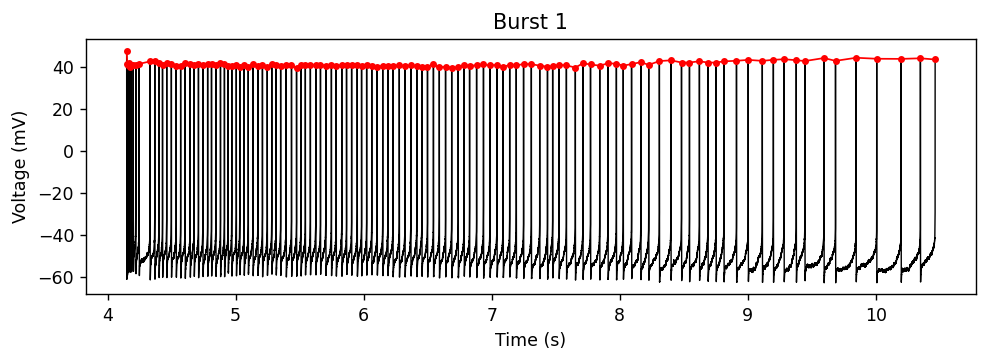

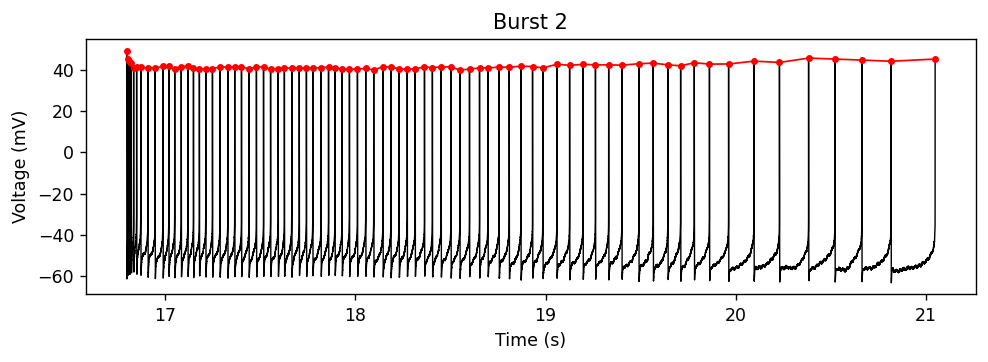

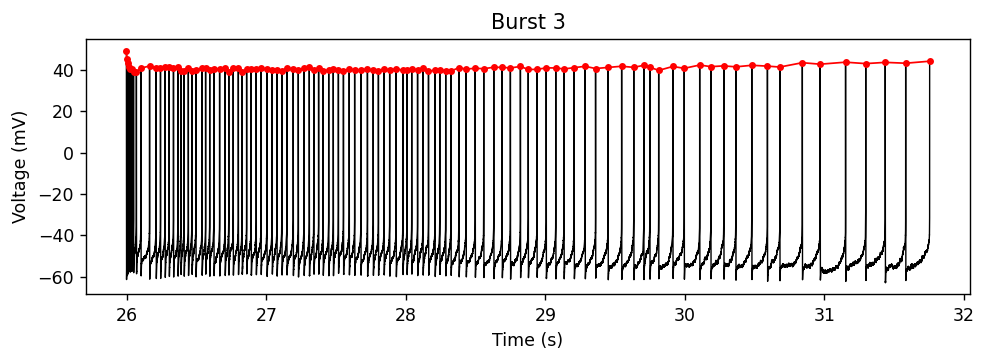

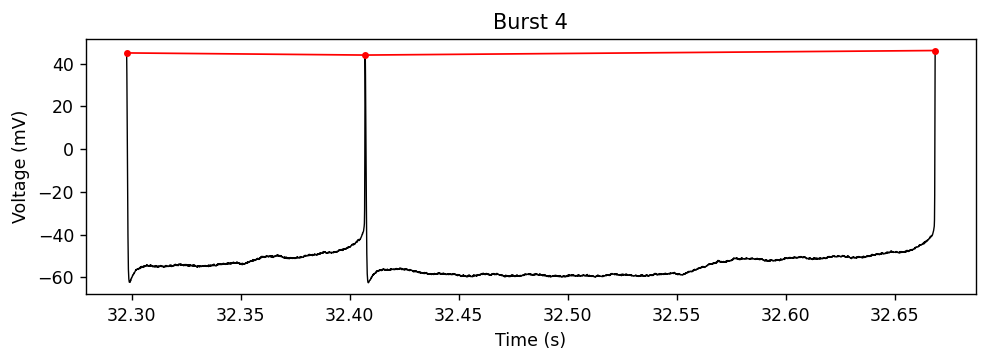

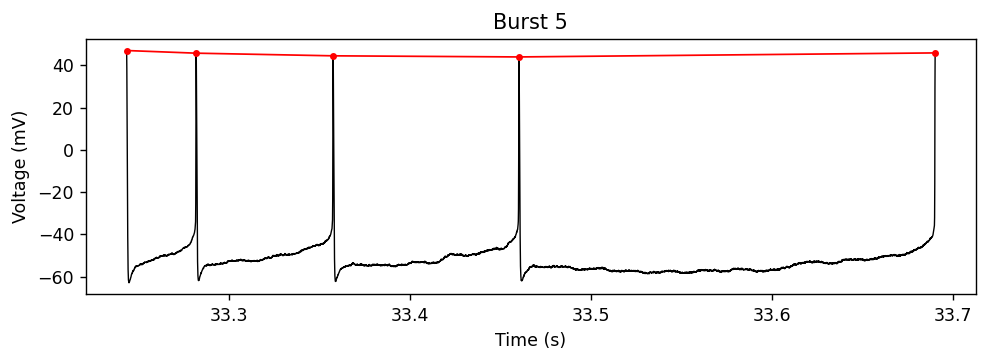

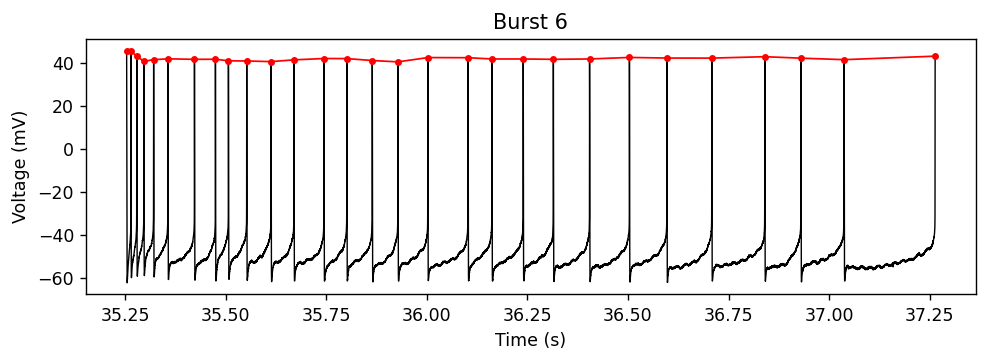

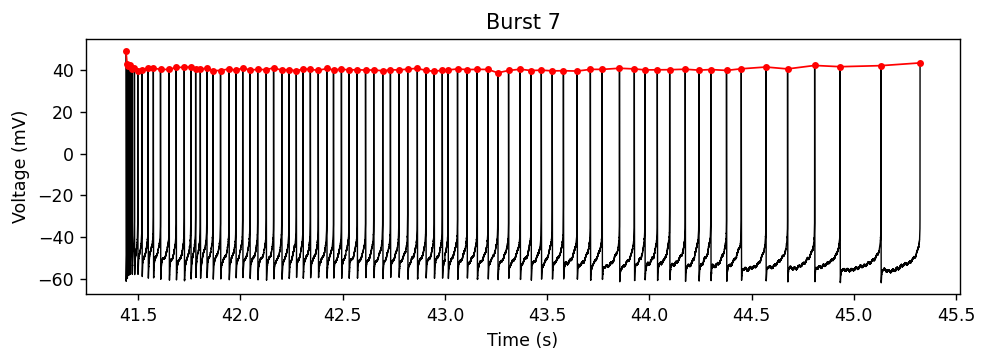

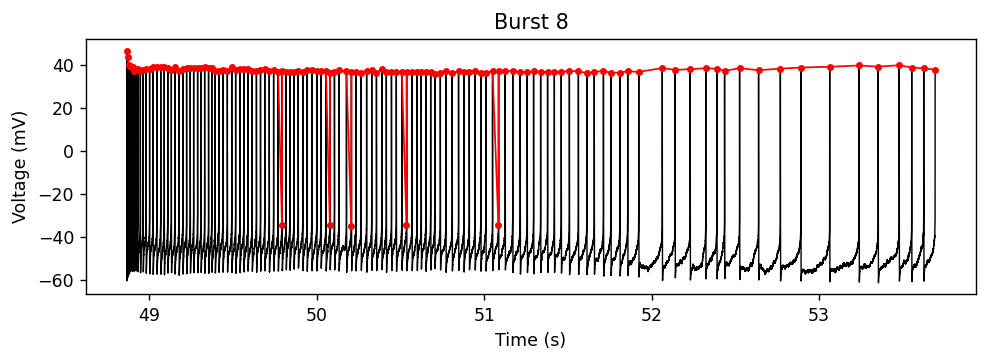

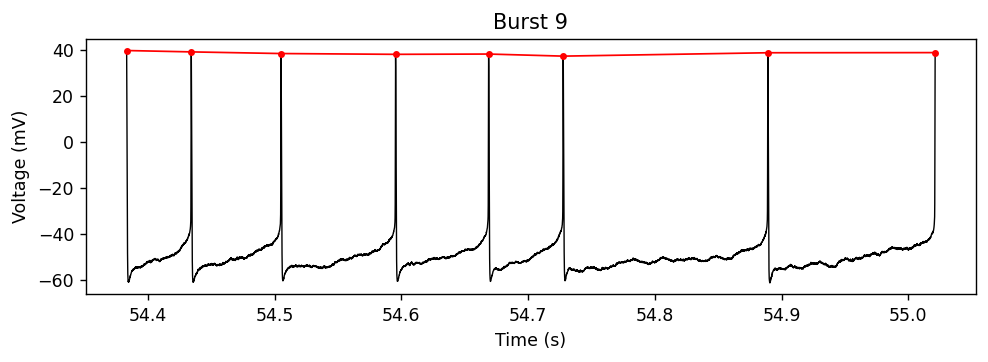

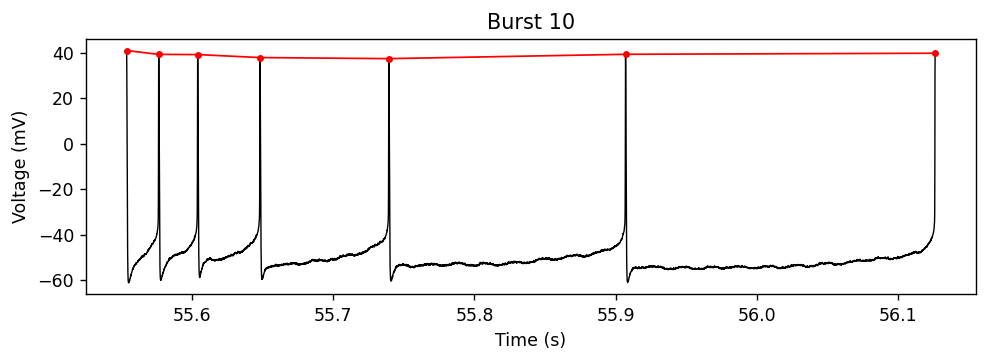

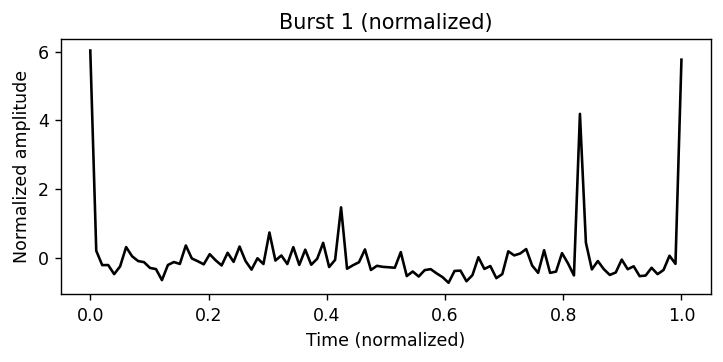

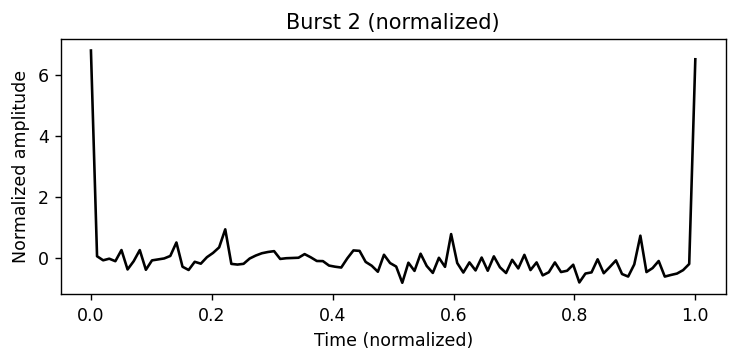

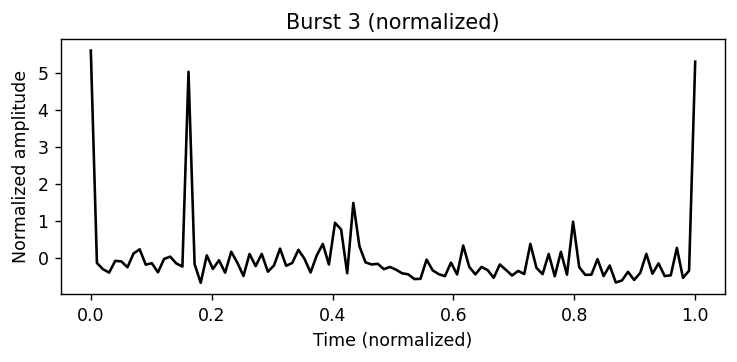

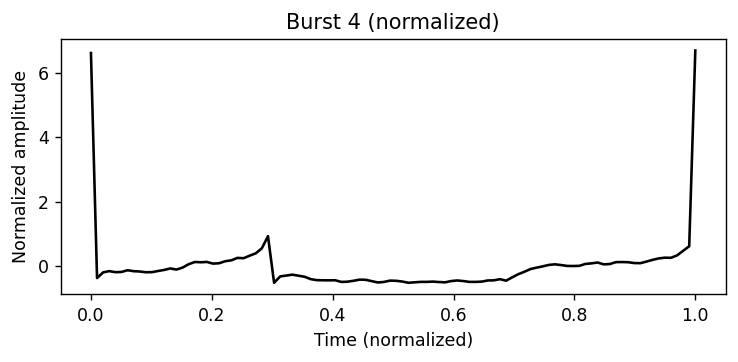

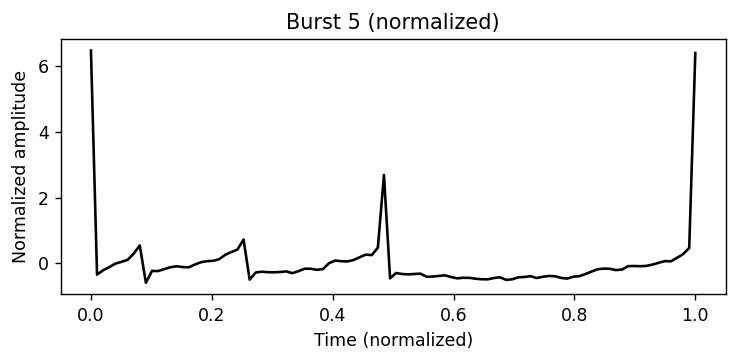

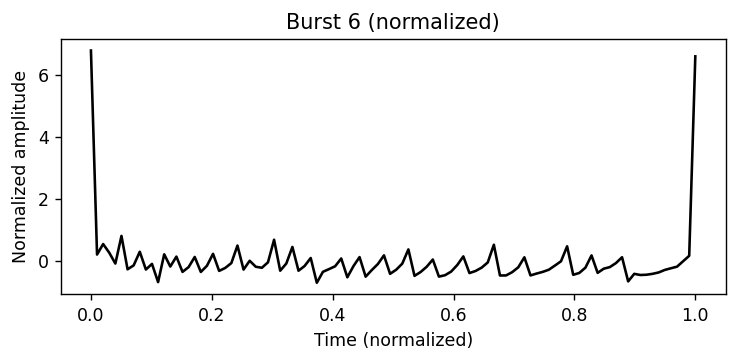

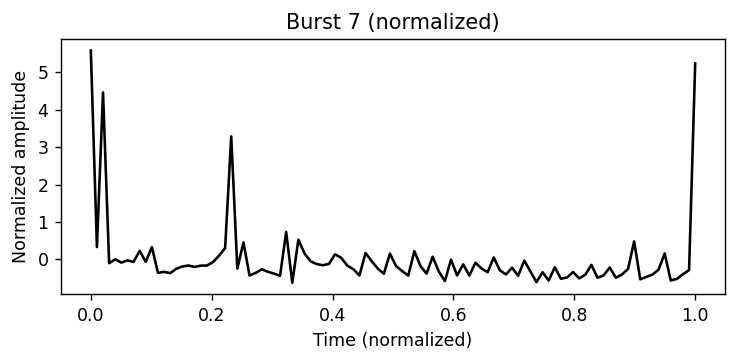

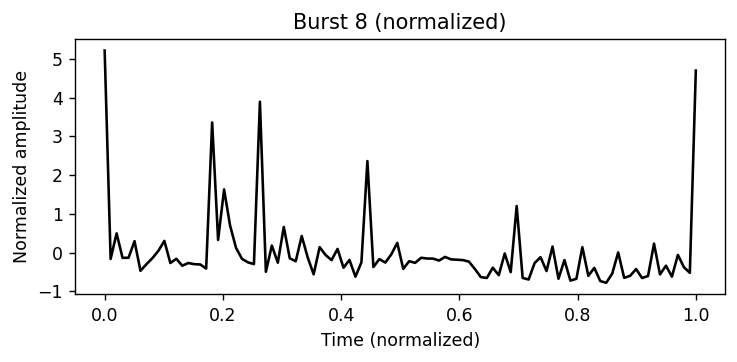

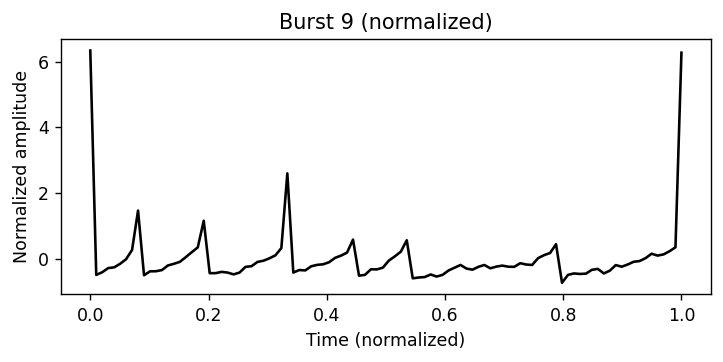

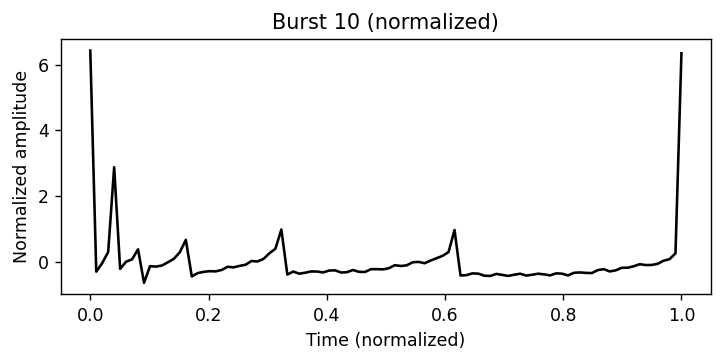

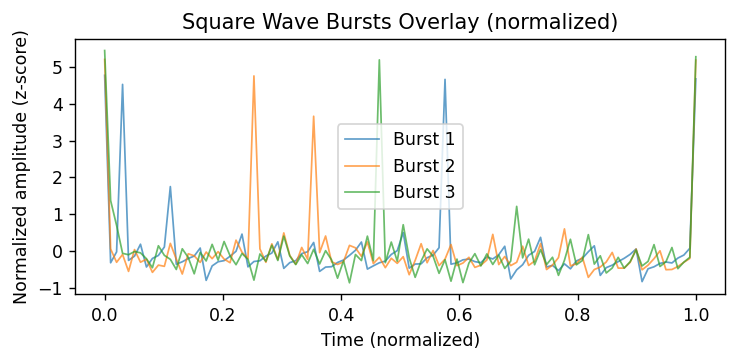

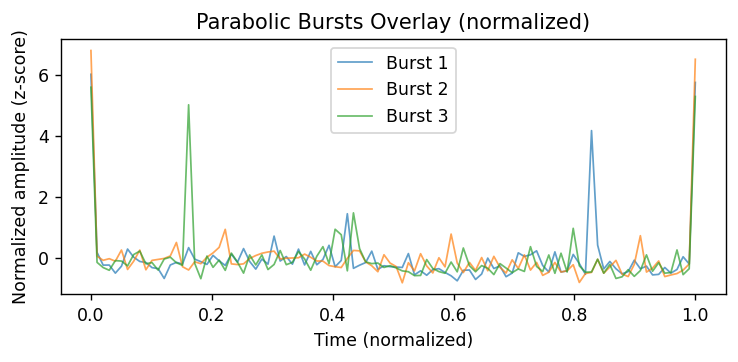

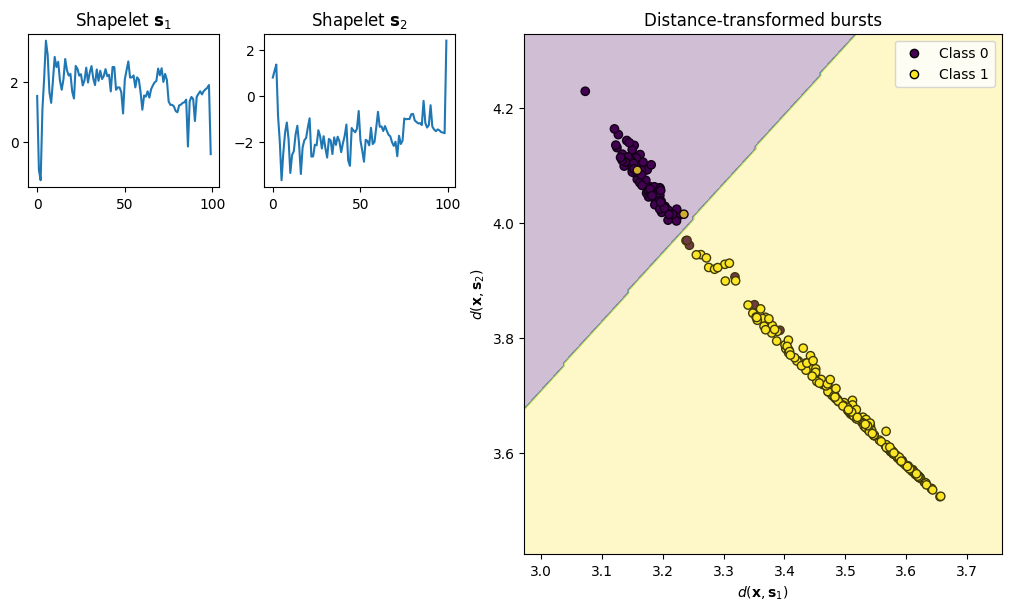

In [ ]:

# Imports: Core Libraries for Shapelet Learning & Plotting

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm                                # For color maps 
from tslearn.preprocessing import TimeSeriesScalerMinMax # For rescaling time series to [0,1]
from tslearn.shapelets import LearningShapelets          # Shapelet-learning model
from tensorflow.keras.optimizers import Adam          


# Data Preparation

# "all_normalized_bursts" and "labels" come from your preprocessing pipeline
# Each burst is a normalized 1D waveform, and each label indicates its class:
# 0 = Square Wave, 1 = Parabolic, 2 = Other

# Convert the list of bursts into a 3D NumPy array (n_samples, time_length, n_channels)
# Shapelet models in tslearn expect this 3D structure even for univariate data.
X = np.array(all_normalized_bursts)[:, :, np.newaxis]  # Add 3rd dim = 1 channel
y = np.array(labels)

# Normalize each burst to range [0, 1]
# The z-scoring from before made the mean=0, std=1. This now rescales all values to [0,1]
# This helps the shapelet-learning network converge more easily.
X = TimeSeriesScalerMinMax().fit_transform(X)


# Shapelet Model Configuration

# Shapelets are short, discriminative subsequences learned directly from data.
# They act like "templates" that best separate classes based on distance patterns.

# Define how many shapelets to learn per series length.
# Here, each burst has X.shape[1] points, and we learn 2 shapelets of that full length.
n_shapelets_per_size = {X.shape[1]: 2}

# Initialize the shapelet learner (a neural net under the hood)
shp_clf = LearningShapelets(
    n_shapelets_per_size=n_shapelets_per_size,  # Dict: {length: num_shapelets}
    weight_regularizer=0.0001,   # L2 regularization term to prevent overfitting
    optimizer=Adam(0.01),        # Adam optimizer (adaptive learning rate)
    max_iter=300,                # Train for up to 300 epochs
    verbose=0,                   # Suppress console output
    scale=False,                 # Don't scale shapelets automatically
    random_state=42              # Reproducibility
)


# Training the Shapelet Model

# The model jointly learns:
#   1. The shapelets themselves (short subsequences)
#   2. A classifier that uses the distances to these shapelets as features
#
# Objective: minimize classification loss while learning shapelets that best
# differentiate between classes based on time-series patterns.

shp_clf.fit(X, y)


# Transform Each Burst into Shapelet-Distance Space

# After learning, each burst (time series) can be represented by its
# Euclidean distances to each learned shapelet. Here we have 2 shapelets, 2D space.

distances = shp_clf.transform(X).reshape((-1, 2))


# Visualization Setup

# We'll visualize:
#   - The learned shapelets themselves
#   - A 2D scatter of bursts in shapelet-distance space
#   - Decision boundaries between classes

%matplotlib inline
viridis = cm.get_cmap('viridis', 4)    # Nice perceptually uniform colormap
fig = plt.figure(constrained_layout=True, figsize=(10,6))
gs = fig.add_gridspec(3, 9)

# Define subplots:
fig_ax1 = fig.add_subplot(gs[0, :2])   # Shapelet 1
fig_ax2 = fig.add_subplot(gs[0, 2:4])  # Shapelet 2
fig_ax4 = fig.add_subplot(gs[:, 4:])   # 2D projection of bursts


# Plot Learned Shapelets

# The learned shapelets represent prototypical burst morphologies.
# You can think of them as "average patterns" the classifier uses to distinguish classes.

fig_ax1.plot(shp_clf.shapelets_[0].flatten())
fig_ax1.set_title('Shapelet $\\mathbf{s}_1$')

fig_ax2.plot(shp_clf.shapelets_[1].flatten())
fig_ax2.set_title('Shapelet $\\mathbf{s}_2$')


# Scatter Plot of Transformed Bursts

# Each burst is plotted in the 2D space defined by distances to the two shapelets:
#    x-axis = distance to shapelet 1
#    y-axis = distance to shapelet 2
# Bursts close to a shapelet (low distance) are similar to that pattern.

for i, label in enumerate(np.unique(y)):
    mask = y == label
    fig_ax4.scatter(
        distances[mask][:,0],              # Distance to shapelet 1
        distances[mask][:,1],              # Distance to shapelet 2
        c=[viridis(i / max(1, len(np.unique(y)) - 1))]*np.sum(mask),
        edgecolors='k',
        label=f'Class {label}'
    )


# Compute Decision Boundaries in Shapelet Space

# We'll visualize how the trained classifier separates the space.
# For every (x, y) point, we compute the predicted class.

# Define the grid boundaries (a little wider than data points)
xmin, xmax = distances[:,0].min()-0.1, distances[:,0].max()+0.1
ymin, ymax = distances[:,1].min()-0.1, distances[:,1].max()+0.1
xx, yy = np.meshgrid(np.linspace(xmin, xmax, 200),
                     np.linspace(ymin, ymax, 200))

# Extract weights (W) and biases (b) from the classification layer
# These define linear decision boundaries in the 2D distance space
W, b = shp_clf.model_.get_layer("classification").get_weights()
n_classes = len(np.unique(y))

# Compute predictions across the grid
Z = []
for x_val, y_val in np.c_[xx.ravel(), yy.ravel()]:
    if n_classes == 2:
        # Binary: logistic decision boundary
        logit = b[0] + W[0,0]*x_val + W[1,0]*y_val
        pred = int(logit >= 0)
    else:
        # Multiclass: pick class with highest linear score
        scores = [b[i] + W[0,i]*x_val + W[1,i]*y_val for i in range(n_classes)]
        pred = np.argmax(scores)
    Z.append(pred)

# Reshape predictions into the same grid form for contour plotting
Z = np.array(Z).reshape(xx.shape)

# Overlay decision boundaries as color regions
fig_ax4.contourf(xx, yy, Z/max(1, n_classes-1), cmap=viridis, alpha=0.25)


# Final Plot Styling
fig_ax4.set_xlabel('$d(\\mathbf{x}, \\mathbf{s}_1)$')  # Distance to shapelet 1
fig_ax4.set_ylabel('$d(\\mathbf{x}, \\mathbf{s}_2)$')  # Distance to shapelet 2
fig_ax4.set_xlim(xmin, xmax)
fig_ax4.set_ylim(ymin, ymax)
fig_ax4.set_title('Distance-transformed bursts')
fig_ax4.legend()
plt.show()